<a href="https://colab.research.google.com/github/dosawaru/cse_572_project/blob/main/CSE572.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Dataset

In [113]:
import zipfile
import os

# Phishing Email Dataset
zip_path = 'dataset.zip'

# Extract ZIP
extract_dir = "dataset"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extracted files:", os.listdir(extract_dir))
print("Dataset Loaded!")

Extracted files: ['phishing_email.csv', 'Nigerian_Fraud.csv', 'Enron.csv', 'CEAS_08.csv', 'SpamAssasin.csv', 'Nazario.csv', 'Ling.csv']
Dataset Loaded!


## Data Acquisition & Consolidation

In [114]:
import pandas as pd
import os

folder = "dataset"
csv_files = [f for f in os.listdir(folder) if f.endswith(".csv") and f != "phishing_email.csv"]

dfs = []

print(f"CSV files: {len(csv_files)}")

for file in csv_files:
    file_path = os.path.join(folder, file)
    df = pd.read_csv(file_path, encoding="latin1", on_bad_lines="skip")
    df["source"] = file
    dfs.append(df)
    print(f"Successfully loaded '{file}' with {len(df)} rows")

# Combine all csv into a single DataFrame
data = pd.concat(dfs, ignore_index=True)
print(f"\nCombined Shape: {data.shape}")

# Create a new column called 'text_combined' (combines subject, body, sender)
data['text_combined'] = ""
columns_to_combine = ['sender', 'subject', 'body']

# Ignores NaN values
data['text_combined'] = data[columns_to_combine].fillna('').agg(' '.join, axis=1)
data.head(3)



CSV files: 6
Successfully loaded 'Nigerian_Fraud.csv' with 3332 rows
Successfully loaded 'Enron.csv' with 29767 rows
Successfully loaded 'CEAS_08.csv' with 39154 rows
Successfully loaded 'SpamAssasin.csv' with 5809 rows
Successfully loaded 'Nazario.csv' with 1565 rows
Successfully loaded 'Ling.csv' with 2859 rows

Combined Shape: (82486, 8)


,sender,receiver,date,subject,body,urls,label,source,text_combined
0,MR. JAMES NGOLA. <james_ngola2002@maktoob.com>,webmaster@aclweb.org,"Thu, 31 Oct 2002 02:38:20 +0000",URGENT BUSINESS ASSISTANCE AND PARTNERSHIP,"FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-27-587908.\nE-MAIL: (james_ngola2002@maktoob.com).\n\nURGENT BUSINESS ASSISTANCE AND PARTNERSHIP.\n\n\nDEAR FRIEND,\n\nI AM ( DR.) JAMES NGOLA, THE PERSONAL ASSISTANCE TO THE LATE CONGOLESE (PRESIDENT LAURENT KABILA) WHO WAS ASSASSINATED BY HIS BODY GUARD ON 16TH JAN. 2001.\n\n\nTHE INCIDENT OCCURRED IN OUR PRESENCE WHILE WE WERE HOLDING MEETING WITH HIS EXCELLENCY OVER THE FINANCIAL RETURNS FROM THE DIAMOND SALES IN THE AREAS CONTROLLED BY (D.R.C.) DEMOCRATIC REPUBLIC OF CONGO FORCES AND THEIR FOREIGN ALLIES ANGOLA AND ZIMBABWE, HAVING RECEIVED THE PREVIOUS DAY (USD$100M) ONE HUNDRED MILLION UNITED STATES DOLLARS, CASH IN THREE DIPLOMATIC BOXES ROUTED THROUGH ZIMBABWE.\n\nMY PURPOSE OF WRITING YOU THIS LETTER IS TO SOLICIT FOR YOUR ASSISTANCE AS TO BE A COVER TO THE FUND AND ALSO COLLABORATION IN MOVING THE SAID FUND INTO YOUR BANK ACCOUNT THE SUM OF (USD$25M) TWENTY FIVE MILLION UNITED STATES DOLLARS ONLY, WHICH I DEPOSITED WITH A SECURITY COMPANY IN GHANA, IN A DIPLOMATIC BOX AS GOLDS WORTH (USD$25M) TWENTY FIVE MILLION UNITED STATES DOLLARS ONLY FOR SAFE KEEPING IN A SECURITY VAULT FOR ANY FURTHER INVESTMENT PERHAPS IN YOUR COUNTRY. \n\nYOU WERE INTRODUCED TO ME BY A RELIABLE FRIEND OF MINE WHO IS A TRAVELLER,AND ALSO A MEMBER OF CHAMBER OF COMMERCE AS A RELIABLE AND TRUSTWORTHY PERSON WHOM I CAN RELY ON AS FOREIGN PARTNER, EVEN THOUGH THE NATURE OF THE TRANSACTION WAS NOT REVEALED TO HIM FOR SECURITY REASONS.\n\n\nTHE (USD$25M) WAS PART OF A PROCEEDS FROM DIAMOND TRADE MEANT FOR THE LATE PRESIDENT LAURENT KABILA WHICH WAS DELIVERED THROUGH ZIMBABWE IN DIPLOMATIC BOXES. THE BOXES WERE KEPT UNDER MY CUSTODY BEFORE THE SAD EVENT THAT TOOK THE LIFE OF (MR. PRESIDENT).THE CONFUSION THAT ENSUED AFTER THE ASSASSINATION AND THE SPORADIC SHOOTING AMONG THE FACTIONS, I HAVE TO RUN AWAY FROM THE COUNTRY FOR MY DEAR LIFE AS I AM NOT A SOLDIER BUT A CIVIL SERVANT I CROSSED RIVER CONGO TO OTHER SIDE OF CONGO LIBREVILLE FROM THERE I MOVED TO THE THIRD COUNTRY GHANA WHERE I AM PRESENTLY TAKING REFUGE. \n\nAS A MATTER OF FACT, WHAT I URGENTLY NEEDED FROM YOU IS YOUR ASSISTANCE IN MOVING THIS MONEY INTO YOUR ACCOUNT IN YOUR COUNTRY FOR INVESTMENT WITHOUT RAISING EYEBROW. FOR YOUR ASSISTANCE I WILL GIVE YOU 20% OF THE TOTAL SUM AS YOUR OWN SHARE WHEN THE MONEY GETS TO YOUR ACCOUNT, WHILE 75% WILL BE FOR ME, OF WHICH WITH YOUR KIND ADVICE I HOPE TO INVEST IN PROFITABLE VENTURE IN YOUR COUNTRY IN OTHER TO SETTLE DOWN FOR MEANINGFUL LIFE, AS I AM TIRED OF LIVING IN A WAR ENVIRONMENT. \n\nTHE REMAINING 5% WILL BE USED TO OFFSET ANY COST INCURRED IN THE CAUSE OF MOVING THE MONEY TO YOUR ACCOUNT. IF THE PROPOSAL IS ACCEPTABLE TO YOU PLEASE CONTACT ME IMMEDIATELY THROUGH THE ABOVE TELEPHONE AND E-MAIL, TO ENABLE ME ARRANGE FACE TO FACE MEETING WITH YOU IN GHANA FOR THE CLEARANCE OF THE FUNDS BEFORE TRANSFRING IT TO YOUR BANK ACCOUNT AS SEEING IS BELIEVING. \n\nFINALLY, IT IS IMPORTANT ALSO THAT I LET YOU UNDERSTAND THAT THERE IS NO RISK INVOLVED WHATSOEVER AS THE MONEY HAD NO RECORD IN KINSHASA FOR IT WAS MEANT FOR THE PERSONAL USE OF (MR. PRESIDEND ) BEFORE THE NEFARIOUS INCIDENT OCCURRED, AND ALSO I HAVE ALL THE NECESSARY DOCUMENTS AS REGARDS TO THE FUNDS INCLUDING THE (CERTIFICATE OF DEPOSIT), AS I AM THE DEPOSITOR OF THE CONSIGNMENT.\n\n\nLOOKING FORWARD TO YOUR URGENT RESPONSE.\n\nYOUR SINCERELY,\n\nMR. JAMES NGOLA. \n\n\n\n\n\n\n\n\n\n\n",0.0,1,Nigerian_Fraud.csv,"MR. JAMES NGOLA. <james_ngola2002@maktoob.com> URGENT BUSINESS ASSISTANCE AND PARTNERSHIP FROM:MR. JAMES NGOLA.\nCONFIDENTIAL TEL: 233-27-587908.\nE-MAIL: (james_ngola2002@maktoob.com).\n\nURGENT BUSINESS ASSISTANCE AND PARTNERSHIP.\n\n\nDEAR FRIEND,\n\nI AM ( DR.) JAMES NGOLA, THE PERSONAL ASSISTANCE TO THE LATE CONGOLESE (PR

We created the text_combined column to put all the important data from an email into one place for the model to study. Since phishing often uses a suspicious sender address along with an urgent subject line and body, merging them makes it easier to see all the information at once rather than looking at pieces separately.

### Feature Fusion





In [115]:
tag = " email_has_url"
mask = (data['urls'] == 1) & (~data['text_combined'].str.contains(tag))
data.loc[mask, 'text_combined'] = data['text_combined'] + tag

data[data['urls'] == 1].head(3)

,sender,receiver,date,subject,body,urls,label,source,text_combined
6,Barrister tunde dosumu <tunde_dosumu@lycos.com>,NaN,NaN,Urgent Attention,"Dear Sir,\n\nI am Barrister Tunde Dosumu (SAN) solicitor at law. I am the personal attorney to Mr. Eton Simon, a national of your country, who used to work with Shell Petroleum Development Company (SPDC)here in Nigeria. Here in after shall be referred to me as my client. On the 21st of April 2000, my client, his wife And their three children were involved in a car accident along Sagbama Express Road. All occupants of the vehicle unfortunately lost there lives. Since then I have made several enquiries to your embassy to locate any of my clients extended relatives this has also proved unsuccessful. \n\nAfter these several unsuccessful attempts, I decided to track his last name over the Internet, to locate any member of his family hence I contacted you. I have contacted you to assist in repatrating the money and property left behind by my client before they get confisicated or declared unserviceable by the bank where this huge deposits were lodged, particularly, the CITI TRUST BANK where the deceased had an account valued at about US$14.7million dollars . The bank has issued me a notice to provide the next of kin or have the account confisicated within the next ten official\nworking days. \n\nSince I have been unsuccesfull in locating the the relatives for over 2 years now I seek your consent to present you as the next of kin of the deceased since\nyou have the same last name so that the proceeds of this account valued at US$14.7 million dollars can be paid to you and then you and me can share the money. I have all necessary legal documents that can be used to back up any claim we may make.\n\nAll I require is your honest co-operation to enable us see this dealthrough. I guarantee that this will be executed under legitimate arrangement that will protect you from any breach of the law.Please get in touch with me via my private email address of barrister_tunde@lawyer.com to enable us discuss further. Or, call me on 234-80-33-432-485\n\nBest regards,\n\n\nBarrister Tunde Dosumu (SAN).\n\n\n__________________________________________________________\nOutgrown your current e-mail service? Get 25MB Storage, POP3 Access,\nAdvanced Spam protection with LYCOS MAIL PLUS.\nhttp://login.mail.lycos.com/brandPage.shtml?pageId=plus&ref=lmtplus\n\n",1.0,1,Nigerian_Fraud.csv,"Barrister tunde dosumu <tunde_dosumu@lycos.com> Urgent Attention Dear Sir,\n\nI am Barrister Tunde Dosumu (SAN) solicitor at law. I am the personal attorney to Mr. Eton Simon, a national of your country, who used to work with Shell Petroleum Development Company (SPDC)here in Nigeria. Here in after shall be referred to me as my client. On the 21st of April 2000, my client, his wife And their three children were involved in a car accident along Sagbama Express Road. All occupants of the vehicle unfortunately lost there lives. Since then I have made several enquiries to your embassy to locate any of my clients extended relatives this has also proved unsuccessful. \n\nAfter these several unsuccessful attempts, I decided to track his last name over the Internet, to locate any member of his family hence I contacted you. I have contacted you to assist in repatrating the money and property left behind by my client before they get confisicated or declared unserviceable by the bank where this huge deposits were lodged, particularly, the CITI TRUST BANK where the deceased had an account valued at about US$14.7million dollars . The bank has issued me a notice to provide the next of kin or have the account confisicated within the next ten official\nworking days. \n\nSince I have been unsuccesfull in locating the the relatives for over 2 years now I seek your consent to present you as the next of kin of the deceased since\nyou have the same last name so that the proceeds of this account valued at US$14.7 million dollars can be paid to you and then y

#### Turning the 1/0 URL indicator into a word:

Creates a Strong Signal: A unique tag can help the model  easily weigh as a high risk for phishing

Prevents Noise During Cleaning: Leave a "1" in the text may cause cleaning to removes all numbers and lose important information

Centralizes Features: It allows to combine your most important metadata into text_combined


## Feature Engineering

In [116]:
import re

# Flag for money symbols ($ or USD)
data['has_money_symbol'] = data['text_combined'].str.contains(r'\$|usd', flags=re.IGNORECASE, regex=True).astype(int)

# Flag for phone numbers
data['has_phone_number'] = data['text_combined'].str.contains(r'\d{3}[-\.\s]??\d{3}[-\.\s]??\d{4}|\d{3}-\d{2}-\d{6}', regex=True).astype(int)

# Calculate ratio of all cap words
data['caps_ratio'] = data['text_combined'].apply(lambda x: len([w for w in str(x).split() if w.isupper() and len(w) > 1]) / max(len(str(x).split()), 1))

data[['has_money_symbol', 'has_phone_number', 'caps_ratio']].head()

,has_money_symbol,has_phone_number,caps_ratio
0,1,1,0.936860
1,1,0,0.011050
2,1,0,0.046595
3,1,0,0.046595
4,1,0,0.007215


Money Symbols: Captures the financial hooks that seen the most scams

Phone Numbers: This flags "callback scams" where attackers share a number for the victim to call

All-Caps Ratio: This captures the urgent formatting typical of spam

You must extract these specific details before cleaning because the text normalization process will permanently delete the capital letters and special symbols that reveal the scam.

## Exploratory Data Analysis (Before Cleaning)

### Dataset Overview

In [117]:
print('Data Info')
print(f'{"-" * 50}')
data.info()

print('\nData Description')
print(f'{"-" * 50}')
display(data.describe(include='object'))
display(data.describe())

Data Info
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sender            49529 non-null  object 
 1   receiver          47768 non-null  object 
 2   date              49377 non-null  object 
 3   subject           82139 non-null  object 
 4   body              82485 non-null  object 
 5   urls              49860 non-null  float64
 6   label             82486 non-null  int64  
 7   source            82486 non-null  object 
 8   text_combined     82486 non-null  object 
 9   has_money_symbol  82486 non-null  int64  
 10  has_phone_number  82486 non-null  int64  
 11  caps_ratio        82486 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 7.6+ MB

Data Description
--------------------------------------------------


,sender,receiver,date,subject,body,source,text_combined
count,49529,47768,49377,82139,82485,82486,82486
unique,31415,6510,48622,49645,82483,6,82486
top,qydlqcws-iacfym@issues.apache.org,user6@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 21:38:18 -0100",CNN.com Daily Top 10,\n\n,CEAS_08.csv,"re : american - english in australia hello ! i ' m working on a thesis concerning attitudes toward america and the use of american - english by australia . i would be interested in hearing from anyone who has researched this field or who knows of recent research . i ' m particularly interested in the methods used to illicit or ascertain the use of target vocabulary ( eg . pharmacist vs chemist , candy vs lollies etc . ) if you can help , please email jmar2 @ mfs01 . cc . monash . edu . au an edited list of responses will be posted on the linguist list thank you , jessica marks = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = jmar2 @ mfs01 . cc . monash . edu . au\r\n"
freq,462,1375,8,2930,3,39154,1


,urls,label,has_money_symbol,has_phone_number,caps_ratio
count,49860.000000,82486.000000,82486.000000,82486.000000,82486.000000
mean,0.678018,0.519979,0.178600,0.064205,0.032581
std,0.467241,0.499604,0.383019,0.245119,0.090195
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.027027
max,1.000000,1.000000,1.000000,1.000000,0.978070


In [118]:
# Check for duplicate rows and drop them
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    data.drop_duplicates(inplace=True)
    print(f"Number of rows after dropping duplicates: {len(data)}")

Number of duplicate rows: 0


### Variable Distribution

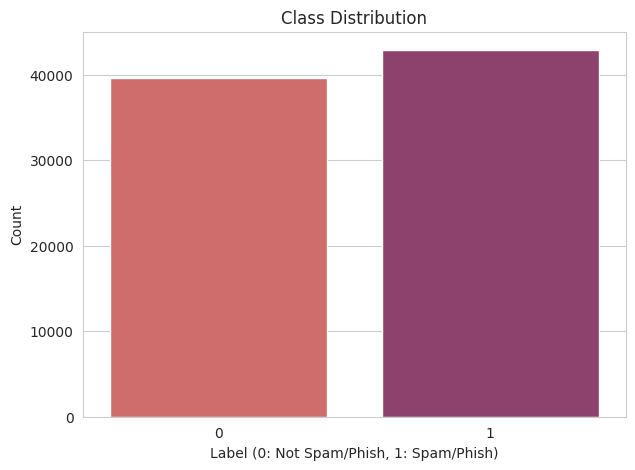

,count
label,
1,42891
0,39595


In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot distribution (Not Spam/Phish vs. Spam/Phish)
plt.figure(figsize=(7,5))
sns.countplot(data=data, x="label", hue="label", palette="flare", legend=False)
plt.title("Class Distribution")
plt.xlabel("Label (0: Not Spam/Phish, 1: Spam/Phish)")
plt.ylabel("Count")
plt.show()

display(data["label"].value_counts())

### Text Length Analysis

Number of empty rows: 0


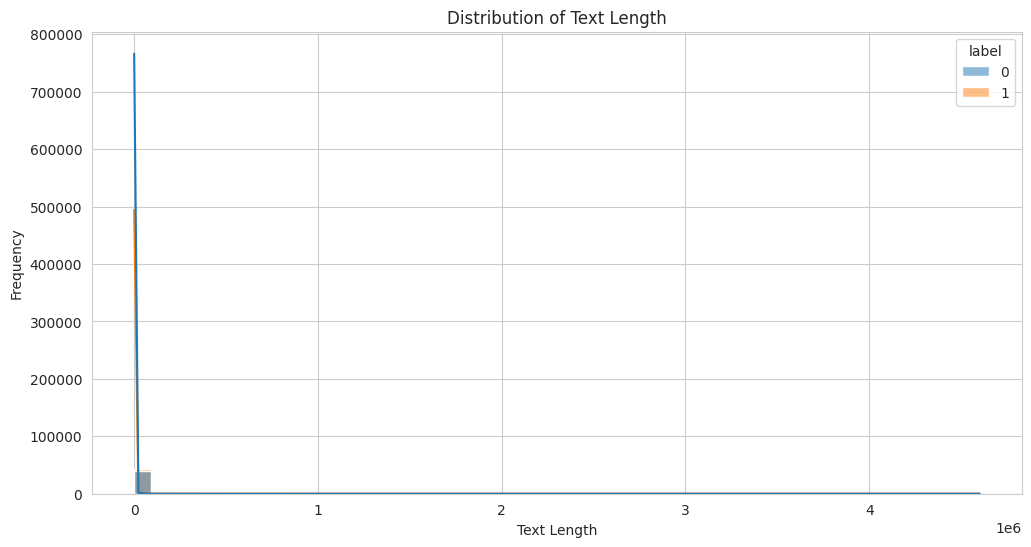

Average text length based on label:


,text_length
label,
0,2228.116075
1,1461.090508


In [120]:
data['text_length'] = data['text_combined'].str.len().fillna(0)

# Handle missing values
print(f"Number of empty rows: {len(data[data['text_length'] == 0])}")

# Plot text length
plt.figure(figsize=(12, 6))
sns.histplot(data=data, x='text_length', hue='label', kde=True, bins=50)
plt.title('Distribution of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

print("Average text length based on label:")
display(data.groupby('label')['text_length'].mean())

The plot shows an extreme positive skew, where a few massive outliers (reaching over 4 million characters) have squashed the rest of your data near zero. This visual suggests you might have some junk data which can be cleaned later on.


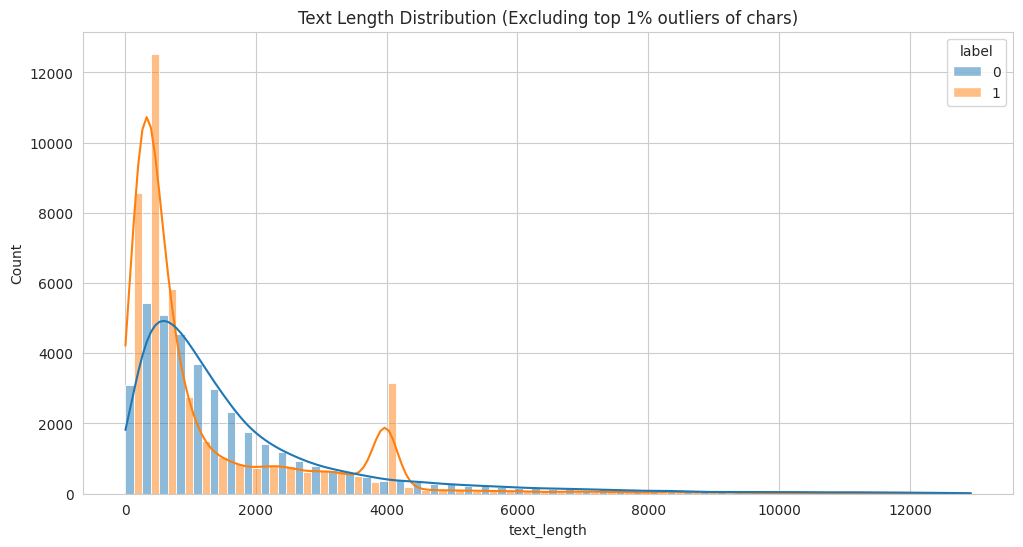

In [121]:
# Filter extreme outlier
limit = data['text_length'].quantile(0.99)
filtered_data = data[data['text_length'] <= limit]

# Filtered version
plt.figure(figsize=(12, 6))
sns.histplot(data=filtered_data, x='text_length', hue='label', kde=True, bins=50, multiple="dodge")
plt.title(f'Text Length Distribution (Excluding top 1% outliers of chars)')
plt.show()

### Word Frequency Analysis

Top 20 Most Frequent Words:
[('the', 641945), ('.', 578953), ('-', 499153), ('to', 476399), (',', 419439), ('of', 367929), ('and', 360003), ('>', 322874), ('a', 285481), ('in', 255218), (':', 191195), ('for', 190799), ('/', 181979), ('is', 177758), ('you', 167595), ('that', 135565), ('this', 135287), ('_', 132409), ('on', 123719), ('your', 120080)]


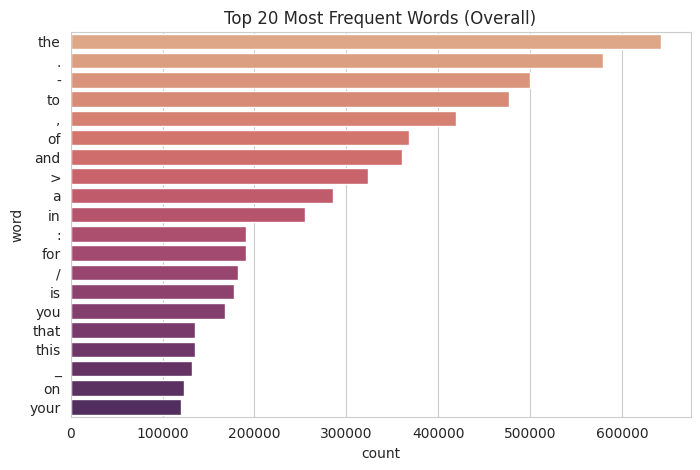

In [122]:
from collections import Counter

# Most frequent words overall
words = " ".join(data["text_combined"].fillna("")).split()

word_freq = Counter(words).most_common(20)
print("Top 20 Most Frequent Words:")
print(word_freq)
df_freq = pd.DataFrame(word_freq, columns=["word", "count"])

plt.figure(figsize=(8,5))
sns.barplot(x="count", y="word", data=df_freq, palette="flare", hue="word", legend=False)
plt.title("Top 20 Most Frequent Words (Overall)")
plt.show()


The chart shows that your dataset is dominated by "noise" like symbols, dates, ID number, etc. This shows that the raw text contains a lot of uncleaned email headers and metadata.

## Data Cleaning

In [123]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### Keeping only letters/underscores and ignore filler words

In [124]:
data['clean_text'] = (data['text_combined'].astype(str).str.lower().str.replace(r'<.*?>', ' ', regex=True).str.replace(r'[^a-z_\s]', ' ', regex=True))

# Apply Stopwords and Lemmatization ()
data['clean_text'] = data['clean_text'].apply(
    lambda text: " ".join([lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words])
)

In [127]:
print("\nCleaned text:")
data['clean_text'].head(1)


Cleaned text:


,clean_text
0,mr james ngola urgent business assistance partnership mr james ngola confidential tel e mail james_ngola maktoob com urgent business assistance partnership dear friend dr james ngola personal assistance late congolese president laurent kabila assassinated body guard th jan incident occurred presence holding meeting excellency financial return diamond sale area controlled r c democratic republic congo force foreign ally angola zimbabwe received previous day usd one hundred million united state dollar cash three diplomatic box routed zimbabwe purpose writing letter solicit assistance cover fund also collaboration moving said fund bank account sum usd twenty five million united state dollar deposited security company ghana diplomatic box gold worth usd twenty five million united state dollar safe keeping security vault investment perhaps country introduced reliable friend mine traveller also member chamber commerce reliable trustworthy person rely foreign partner even though nature transaction revealed security reason usd part proceeds diamond trade meant late president laurent kabila delivered zimbabwe diplomatic box box kept custody sad event took life mr president confusion ensued assassination sporadic shooting among faction run away country dear life soldier civil servant crossed river congo side congo libreville moved third country ghana presently taking refuge matter fact urgently needed assistance moving money account country investment without raising eyebrow assistance give total sum share money get account kind advice hope invest profitable venture country settle meaningful life tired living war environment remaining used offset cost incurred cause moving money account proposal acceptable please contact immediately telephone e mail enable arrange face face meeting ghana clearance fund transfring bank account seeing believing finally important also let understand risk involved whatsoever money record kinshasa meant personal use mr presidend nefarious incident occurred also necessary document regard fund including certificate deposit depositor consignment looking forward urgent response sincerely mr james ngola


 ## Exploratory Data Analysis (After Cleaning)

Top 20 Most Frequent Words:
[('com', 219300), ('http', 169452), ('_', 138965), ('cnn', 116434), ('www', 109721), ('html', 78283), ('email', 69888), ('video', 68985), ('index', 62883), ('e', 61015), ('u', 58932), ('submission', 56079), ('enron', 53892), ('c', 45278), ('id', 43806), ('org', 42661), ('please', 40868), ('mail', 39267), ('one', 38465), ('b', 38459)]


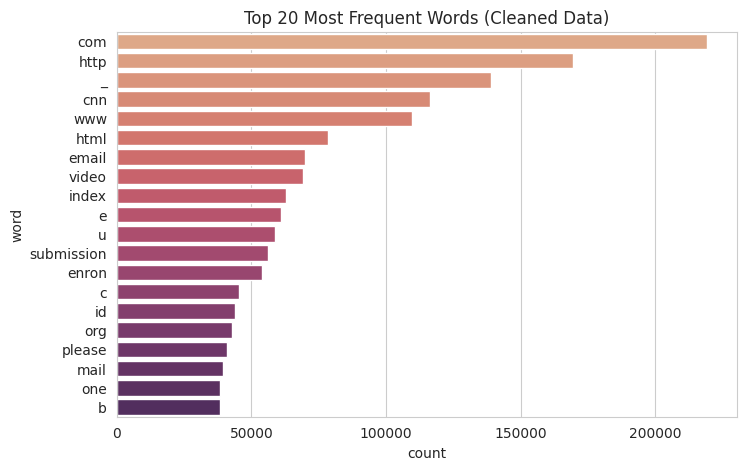

In [128]:
# Most frequent words overall
words = " ".join(data["clean_text"].fillna("")).split()

word_freq = Counter(words).most_common(20)
print("Top 20 Most Frequent Words:")
print(word_freq)
df_freq = pd.DataFrame(word_freq, columns=["word", "count"])

plt.figure(figsize=(8,5))
sns.barplot(x="count", y="word", data=df_freq, palette="flare", hue="word", legend=False)
plt.title("Top 20 Most Frequent Words (Cleaned Data)")
plt.show()
